### Model Evaluation

In the realm of machine learning and data science, evaluating the performance of classification models is crucial for understanding their effectiveness. Various metrics are employed to assess how well a model predicts outcomes, particularly in binary classification tasks. Among these metrics, Recall, Precision, F1-Score, and AUC-ROC are widely recognized for their ability to provide insights into different aspects of model performance. Each metric serves a unique purpose, helping practitioners make informed decisions about model selection and optimization based on the specific requirements of their applications.

### Common evaluation metrics used in model validation, particularly for classification tasks:



- ### **Recall (Sensitivity)**
Recall measures the proportion of actual positive cases that were correctly identified by the model. It is defined as:

$ \text{Recall} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Negatives}} $

- ### **Precision**
Precision measures the accuracy of the positive predictions made by the model. It is defined as:

$\text{Precision} = \frac{\text{True Positives}}{\text{True Positives} + \text{False Positives}} $

- ### **F1-Score**
The F1-score is the harmonic mean of precision and recall. It is useful when you need a balance between precision and recall. It is defined as:

$\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}} $

- ### **Area Under the Receiver Operating Characteristic Curve (AUC-ROC)**
AUC-ROC measures the ability of a model to distinguish between classes. The ROC curve plots the true positive rate (Recall) against the false positive rate at various threshold settings. AUC represents the degree or measure of separability.



In [1]:
from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier

# Create a synthetic dataset
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a Random Forest Classifier
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilities for AUC-ROC

# Calculate metrics
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print the results
print(f"Recall: {recall:.2f}")
print(f"Precision: {precision:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"AUC-ROC: {roc_auc:.2f}")


Recall: 0.85
Precision: 0.89
F1-Score: 0.87
AUC-ROC: 0.93


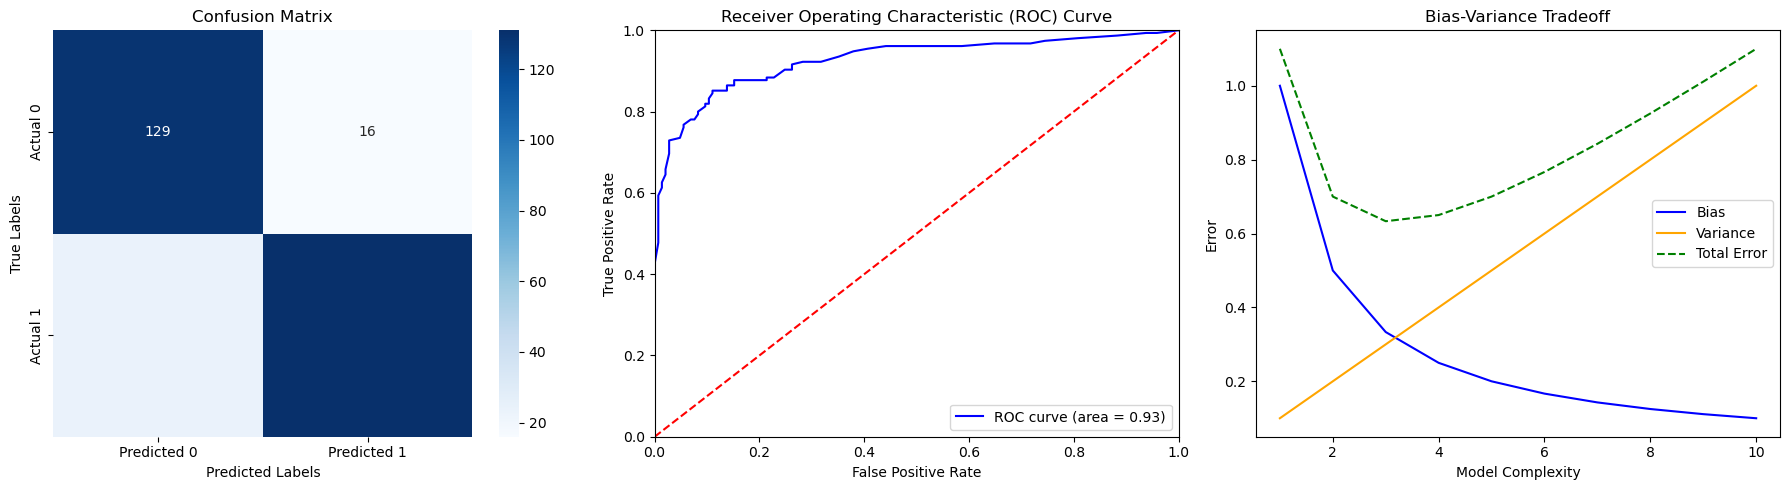

In [3]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

# Plot ROC Curve
plt.subplot(1, 3, 2)
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')  # Diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.0])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')

# Sample data for bias-variance tradeoff
complexity = np.arange(1, 11)
bias = 1 / complexity
variance = complexity / 10

# Plot Bias-Variance Tradeoff
plt.subplot(1, 3, 3)
plt.plot(complexity, bias, label='Bias', color='blue')
plt.plot(complexity, variance, label='Variance', color='orange')
plt.plot(complexity, bias + variance, label='Total Error', color='green', linestyle='--')
plt.xlabel('Model Complexity')
plt.ylabel('Error')
plt.title('Bias-Variance Tradeoff')
plt.legend()

plt.tight_layout()
plt.show()


These graphs provide valuable insights into the performance and behavior of classification models. The confusion matrix helps in understanding the types of errors made by the model. The ROC curve assesses the model's ability to distinguish between classes. The bias-variance tradeoff illustrates the relationship between model complexity and error. Together, they enable data scientists to make informed decisions about model selection, tuning, and evaluation.



### Conclusion
In summary, understanding and utilizing evaluation metrics such as Recall, Precision, F1-Score, and AUC-ROC is essential for effectively validating classification models. Recall focuses on the model's ability to identify all relevant instances, while Precision emphasizes the accuracy of positive predictions. The F1-Score offers a balanced view by combining both Recall and Precision, making it particularly useful in scenarios with class imbalances. Lastly, AUC-ROC provides a comprehensive measure of a model's ability to distinguish between classes across various thresholds. By leveraging these metrics, data scientists can enhance model performance, ensure reliability, and ultimately drive better decision-making in their respective fields.

For example, accuracy is often used as a primary metric for balanced datasets, where the classes are represented equally. However, in imbalanced datasets, accuracy can be misleading, as it may not reflect the model's true performance in identifying the minority class. Each metric serves a unique purpose, helping practitioners make informed decisions about model selection and optimization based on the specific requirements of their applications.

### Identifying and Mitigating Bias and Variance
Bias and variance are two fundamental sources of error in machine learning models that can affect their performance:

1. **Bias** refers to the error due to overly simplistic assumptions in the learning algorithm. High bias can cause an algorithm to miss relevant relations between features and target outputs (underfitting). To identify bias, one can look for:
   - Poor performance on both training and validation datasets.
   - A model that is too simple (e.g., linear regression for a non-linear problem).

   **Mitigation Strategies:**
   - Use more complex models (e.g., decision trees, neural networks).
   - Increase the number of features or use feature engineering techniques.

2. **Variance** refers to the error due to excessive sensitivity to fluctuations in the training dataset. High variance can cause an algorithm to model the random noise in the training data rather than the intended outputs (overfitting). To identify variance, one can look for:
   - Good performance on the training dataset but poor performance on the validation dataset.
   - A model that is too complex (e.g., a deep neural network with insufficient data).

   **Mitigation Strategies:**
   - Use techniques like cross-validation to ensure the model generalizes well.
   - Apply regularization methods (e.g., L1 or L2 regularization) to penalize overly complex models.
   - Prune decision trees or reduce the depth of neural networks.


In conclusion, a comprehensive understanding of evaluation metrics, along with the ability to identify and mitigate bias and variance, is vital for developing effective machine learning models. By carefully selecting appropriate metrics and employing strategies to address bias and variance, data scientists can build robust models that perform well across various scenarios, ultimately leading to more accurate predictions and better decision-making in their respective fields.